In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')

In [2]:
y = pd.get_dummies(df.Gender, prefix='is')
df['Is Female']=y['is_Female']
df = df.drop(["Gender","CustomerID"], axis =1)

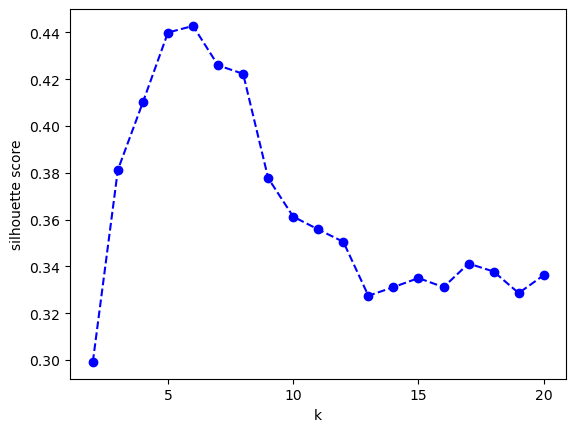

In [3]:
def get_agg_score(data, k):
    agg_clust = AgglomerativeClustering(n_clusters=k)
    model = agg_clust.fit(data)
    return silhouette_score(data, model.labels_, metric='euclidean')

results = []
k_list = list(range(2,21))

for k in k_list:
    results.append(get_agg_score(df, k))

plt.plot(k_list, results, linestyle='--', marker='o', color='b')
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.locator_params(integer=True)


Text(0.5, 0, 'Spending Score')

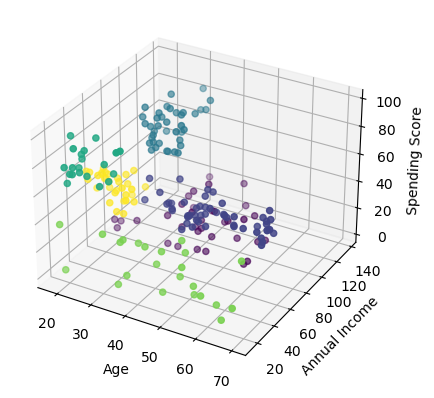

In [4]:
# %matplotlib notebook

agg_clust_6 = AgglomerativeClustering(n_clusters=6)
model_6 = agg_clust_6.fit(df)
labels_6 = model_6.fit_predict(df)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df["Age"], df["Annual Income (k$)"], df["Spending Score (1-100)"], c=labels_6)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')